In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install noisereduce

In [4]:
import numpy as np
import librosa
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
import noisereduce as nr

# ── Dataset config ──────────────────────────────────────────
DATASET_PATH = "/content/drive/MyDrive/audio data/Processed_EATD"
depression_folder = 'Depressed'
normal_folder = 'Normal'
SAMPLE_RATE    = 22050
N_MFCC         = 40

print("=" * 60)
print("  DEPRESSION DETECTION  –  SVM")
print("=" * 60)
print(f"Dataset   : {DATASET_PATH}")
print(f"MFCC coeff: {N_MFCC}")
print(f"Features  : MFCC (mean+std) + ZCR (mean+std) + RMS (mean+std) + Pitch/F0 (mean+std)")
print("=" * 60)


  DEPRESSION DETECTION  –  SVM
Dataset   : /content/drive/MyDrive/audio data/Processed_EATD
MFCC coeff: 40
Features  : MFCC (mean+std) + ZCR (mean+std) + RMS (mean+std) + Pitch/F0 (mean+std)


In [7]:
def extract_features(file_path, sr=SAMPLE_RATE, n_mfcc=N_MFCC):
    try:
        audio, _ = librosa.load(file_path, sr=sr)

        # skip empty or too-short files
        MIN_SAMPLES = 2048          # need at least one FFT frame
        if audio is None or len(audio) < MIN_SAMPLES:
            print(f"  Skipped (too short / empty) – {file_path}")
            return None
        # ──────────────────────────────────────────────────────────────

        audio = nr.reduce_noise(y=audio, sr=sr)

        # Same guard after noise reduction (can occasionally zero out audio)
        if len(audio) < MIN_SAMPLES:
            print(f"  Skipped (empty after denoising) – {file_path}")
            return None

        # 1) MFCC
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfccs, axis=1)
        mfcc_std  = np.std(mfccs,  axis=1)

        # 2) Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y=audio)
        zcr_mean = np.mean(zcr)
        zcr_std  = np.std(zcr)

        # 3) RMS Energy
        rms = librosa.feature.rms(y=audio)
        rms_mean = np.mean(rms)
        rms_std  = np.std(rms)

        # 4) Pitch (F0) via pyin
        f0, voiced_flag, voiced_probs = librosa.pyin(
            audio, fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'), sr=sr
        )
        f0 = np.nan_to_num(f0, nan=0.0)
        f0_mean = np.mean(f0)
        f0_std  = np.std(f0)

        return np.concatenate([
            mfcc_mean, mfcc_std,
            [zcr_mean, zcr_std],
            [rms_mean, rms_std],
            [f0_mean,  f0_std]
        ])  # shape (86,)

    except Exception as e:
        print(f"  Error – {file_path}: {e}")
        return None

In [8]:
def load_dataset(dataset_path):
    features, labels = [], []

    categories = {
        'depression': depression_folder,
        'normal': normal_folder
    }

    for label, folder_name in categories.items():
        folder_full_path = os.path.join(dataset_path, folder_name)

        if not os.path.exists(folder_full_path):
            print(f"  Warning: Folder not found -> {folder_full_path}")
            continue

        # Get list of supported audio files
        files = [f for f in os.listdir(folder_full_path)
                 if f.lower().endswith((".wav", ".mp3", ".flac", ".m4a"))]

        print(f"  [{label}] Found {len(files)} files.")

        for fname in files:
            file_path = os.path.join(folder_full_path, fname)

            feat = extract_features(file_path)

            if feat is not None:
                features.append(feat)
                labels.append(label)

    return np.array(features), np.array(labels)


X, y = load_dataset(DATASET_PATH)

  [depression] Found 90 files.
  [normal] Found 90 files.
  Skipped (too short / empty) – /content/drive/MyDrive/audio data/Processed_EATD/Normal/v_79_positive_out.wav


In [9]:
from sklearn.model_selection import train_test_split

# Encode labels
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

# Stratified Split keeps the 'depression' vs 'normal' ratio the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc,
    shuffle=True
)

# 3. Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Total samples: {len(X)}")
print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")
print(f"Classes in Train: {np.unique(y_train, return_counts=True)}")
print(f"Classes in Test: {np.unique(y_test, return_counts=True)}")

Total samples: 179
Train: 143 samples | Test: 36 samples
Classes in Train: (array([0, 1]), array([72, 71]))
Classes in Test: (array([0, 1]), array([18, 18]))


# **Support vector machine**

In [10]:
# ── Hyperparameter Tuning & Cross-Validation ───────────────
from sklearn.model_selection import StratifiedKFold # Changed from GroupKFold
from sklearn.svm import SVC

print("\n[INFO] Starting Hyperparameter Tuning (Grid Search)...")
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'linear']
}

# Use StratifiedKFold to ensure class balance in each fold
# No 'groups' parameter needed for StratifiedKFold itself during definition
stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=stratified_kfold, # Use stratified_kfold
    scoring='accuracy',
    verbose=1
)
# Pass only X_train and y_train; no 'groups' for GridSearchCV when using StratifiedKFold
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

svm_model = grid_search.best_estimator_


[INFO] Starting Hyperparameter Tuning (Grid Search)...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8602


In [11]:
# ── 6. Final Evaluation ───────────────────────────────────────
print("\n" + "="*30 + " FINAL TEST EVALUATION " + "="*30)
y_pred = svm_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))


============================== FINAL TEST EVALUATION ==============================
Test Accuracy: 91.67%

Classification Report:
               precision    recall  f1-score   support

  depression       0.89      0.94      0.92        18
      normal       0.94      0.89      0.91        18

    accuracy                           0.92        36
   macro avg       0.92      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



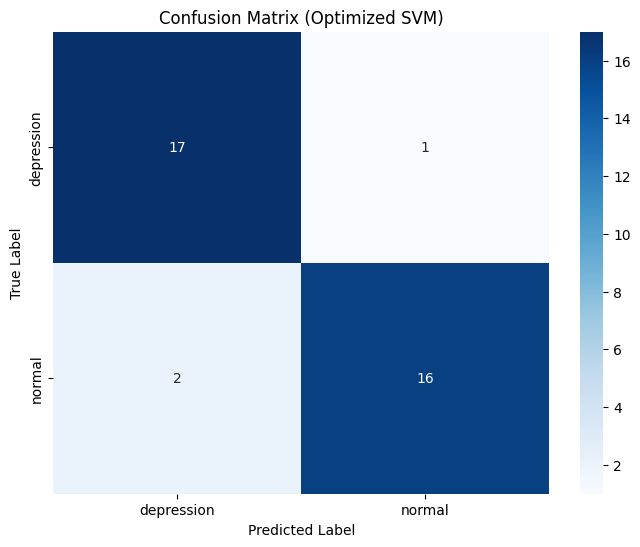

Optimized model and artefacts saved successfully.


In [12]:
# ── 7. Visualizations & Saving ────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix (Optimized SVM)")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.show()

# Save Artefacts
base = "/content/drive/MyDrive/"
with open(base + "svm_depression_model.pkl", "wb") as f: pickle.dump(svm_model, f)
with open(base + "depression_scaler.pkl", "wb") as f: pickle.dump(scaler, f)
with open(base + "depression_label_encoder.pkl", "wb") as f: pickle.dump(label_encoder, f)
print("Optimized model and artefacts saved successfully.")


# **K-NEAREST NEIGHBORS (KNN)**

  KNN – Hyperparameter Tuning & Cross-Validation
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Accuracy: 0.7690

============================== KNN TEST EVALUATION ==============================
Test Accuracy: 88.89%

Classification Report:
               precision    recall  f1-score   support

  depression       0.85      0.94      0.89        18
      normal       0.94      0.83      0.88        18

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.89      0.89      0.89        36



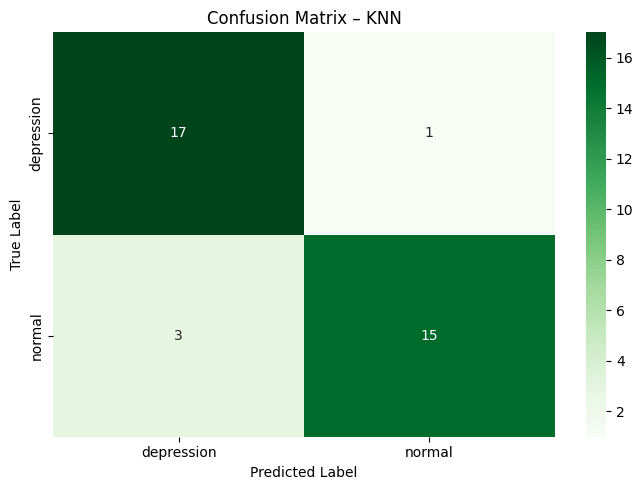

In [13]:
# ══════════════════════════════════════════════════════════════
#  K-NEAREST NEIGHBORS (KNN)
# ══════════════════════════════════════════════════════════════
from sklearn.neighbors import KNeighborsClassifier

print("=" * 60)
print("  KNN – Hyperparameter Tuning & Cross-Validation")
print("=" * 60)

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

knn_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=knn_cv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)

print(f"\nBest Parameters : {knn_grid.best_params_}")
print(f"Best CV Accuracy: {knn_grid.best_score_:.4f}")

knn_model = knn_grid.best_estimator_

# ── Evaluation ────────────────────────────────────────────────
print("\n" + "=" * 30 + " KNN TEST EVALUATION " + "=" * 30)
y_pred_knn = knn_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_knn) * 100:.2f}%")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d",
            cmap="Greens", xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – KNN")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

# **RANDOM FOREST**

  RANDOM FOREST – Hyperparameter Tuning & Cross-Validation
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters : {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy: 0.8182

============================== RANDOM FOREST TEST EVALUATION ==============================
Test Accuracy: 77.78%

Classification Report:
               precision    recall  f1-score   support

  depression       0.78      0.78      0.78        18
      normal       0.78      0.78      0.78        18

    accuracy                           0.78        36
   macro avg       0.78      0.78      0.78        36
weighted avg       0.78      0.78      0.78        36



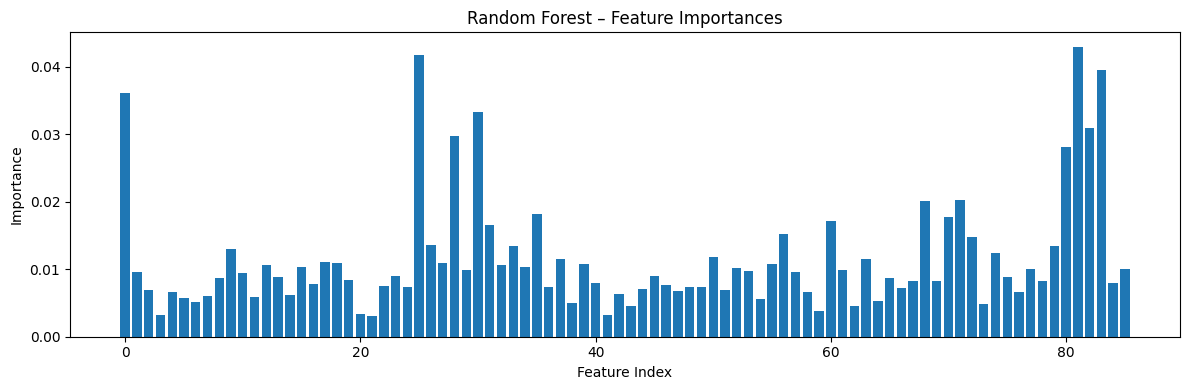

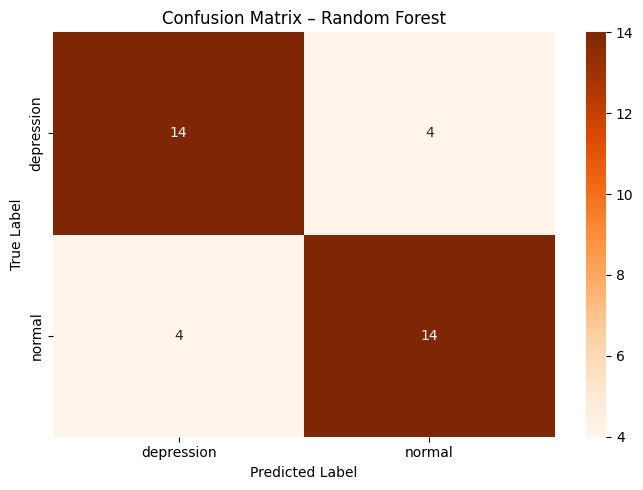

In [14]:
# ══════════════════════════════════════════════════════════════
#  RANDOM FOREST
# ══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("  RANDOM FOREST – Hyperparameter Tuning & Cross-Validation")
print("=" * 60)

rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=rf_cv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"\nBest Parameters : {rf_grid.best_params_}")
print(f"Best CV Accuracy: {rf_grid.best_score_:.4f}")

rf_model = rf_grid.best_estimator_

# ── Evaluation ────────────────────────────────────────────────
print("\n" + "=" * 30 + " RANDOM FOREST TEST EVALUATION " + "=" * 30)
y_pred_rf = rf_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

# Feature Importance
importances = rf_model.feature_importances_
plt.figure(figsize=(12, 4))
plt.bar(range(len(importances)), importances)
plt.title("Random Forest – Feature Importances")
plt.xlabel("Feature Index"); plt.ylabel("Importance")
plt.tight_layout(); plt.show()

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d",
            cmap="Oranges", xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – Random Forest")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

# **CNN**

In [16]:
# ══════════════════════════════════════════════════════════════
#  CNN  (1-D Convolution over feature vector)
# ══════════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np


In [17]:

# ── Helper: build CNN ─────────────────────────────────────────
def build_cnn(input_dim, filters=64, kernel_size=3,
              dropout_rate=0.3, learning_rate=0.001):
    inp = keras.Input(shape=(input_dim, 1))
    x = layers.Conv1D(filters, kernel_size, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(filters * 2, kernel_size, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [18]:

# ── Hyperparameter grid ───────────────────────────────────────
cnn_param_grid = [
    {'filters': 32,  'kernel_size': 3, 'dropout_rate': 0.3, 'learning_rate': 0.001},
    {'filters': 64,  'kernel_size': 3, 'dropout_rate': 0.3, 'learning_rate': 0.001},
    {'filters': 64,  'kernel_size': 5, 'dropout_rate': 0.4, 'learning_rate': 0.0005},
    {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.5, 'learning_rate': 0.001},
]

n_splits    = 5
input_dim   = X_train.shape[1]
best_cnn_score = 0
best_cnn_params = None
best_cnn_history = None

for params in cnn_param_grid:
    print(f"\n[CNN] Testing params: {params}")
    fold_scores = []
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        Xf_tr, Xf_val = X_train[tr_idx], X_train[val_idx]
        yf_tr, yf_val = y_train[tr_idx], y_train[val_idx]

        # Reshape for Conv1D: (samples, features, 1)
        Xf_tr  = Xf_tr.reshape(-1, input_dim, 1)
        Xf_val = Xf_val.reshape(-1, input_dim, 1)

        model = build_cnn(input_dim, **params)
        es = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                     restore_best_weights=True)
        model.fit(Xf_tr, yf_tr,
                  validation_data=(Xf_val, yf_val),
                  epochs=50, batch_size=16,
                  callbacks=[es], verbose=0)

        _, val_acc = model.evaluate(Xf_val, yf_val, verbose=0)
        fold_scores.append(val_acc)
        print(f"   Fold {fold+1}: val_acc = {val_acc:.4f}")

    mean_acc = np.mean(fold_scores)
    print(f"  → Mean CV Accuracy: {mean_acc:.4f}")

    if mean_acc > best_cnn_score:
        best_cnn_score  = mean_acc
        best_cnn_params = params

print(f"\nBest CNN Params : {best_cnn_params}")
print(f"Best CV Accuracy: {best_cnn_score:.4f}")




[CNN] Testing params: {'filters': 32, 'kernel_size': 3, 'dropout_rate': 0.3, 'learning_rate': 0.001}
   Fold 1: val_acc = 0.5862
   Fold 2: val_acc = 0.6207
   Fold 3: val_acc = 0.5862
   Fold 4: val_acc = 0.6429
   Fold 5: val_acc = 0.6071
  → Mean CV Accuracy: 0.6086

[CNN] Testing params: {'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.3, 'learning_rate': 0.001}
   Fold 1: val_acc = 0.5172
   Fold 2: val_acc = 0.5172
   Fold 3: val_acc = 0.5172
   Fold 4: val_acc = 0.6071
   Fold 5: val_acc = 0.7500
  → Mean CV Accuracy: 0.5818

[CNN] Testing params: {'filters': 64, 'kernel_size': 5, 'dropout_rate': 0.4, 'learning_rate': 0.0005}
   Fold 1: val_acc = 0.5862
   Fold 2: val_acc = 0.7931
   Fold 3: val_acc = 0.5172
   Fold 4: val_acc = 0.7143
   Fold 5: val_acc = 0.6071
  → Mean CV Accuracy: 0.6436

[CNN] Testing params: {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.5, 'learning_rate': 0.001}
   Fold 1: val_acc = 0.6897
   Fold 2: val_acc = 0.5172
   Fold 3: val_acc = 0.5862

In [21]:
# ── Retrain best CNN on full training set ─────────────────────
X_train_cnn = X_train.reshape(-1, input_dim, 1)
X_test_cnn  = X_test.reshape(-1,  input_dim, 1)

best_cnn_model = build_cnn(input_dim, **best_cnn_params)
es_final = callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                   restore_best_weights=True)
history = best_cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=100, batch_size=16,
    callbacks=[es_final], verbose=1
)



Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5874 - loss: 0.6630 - val_accuracy: 0.6389 - val_loss: 0.6853
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6084 - loss: 0.6165 - val_accuracy: 0.5000 - val_loss: 0.6827
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6503 - loss: 0.6111 - val_accuracy: 0.5278 - val_loss: 0.6828
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7133 - loss: 0.5706 - val_accuracy: 0.5278 - val_loss: 0.6851
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6783 - loss: 0.6048 - val_accuracy: 0.5278 - val_loss: 0.6866
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7273 - loss: 0.5515 - val_accuracy: 0.5000 - val_loss: 0.6869
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7063 - loss: 0.5369 - val_accuracy: 0.5000 - val_loss: 0.6886
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7762 - loss: 0.5031 - val_accuracy: 0.5000 - val_loss:


============================== CNN TEST EVALUATION ==============================
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
Test Accuracy: 50.00%

Classification Report:
               precision    recall  f1-score   support

  depression       0.50      0.94      0.65        18
      normal       0.50      0.06      0.10        18

    accuracy                           0.50        36
   macro avg       0.50      0.50      0.38        36
weighted avg       0.50      0.50      0.38        36



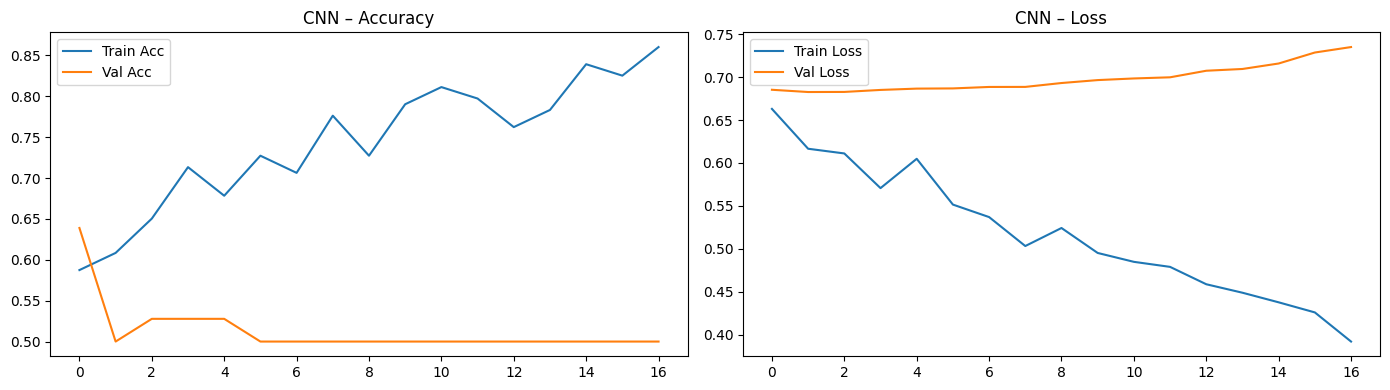

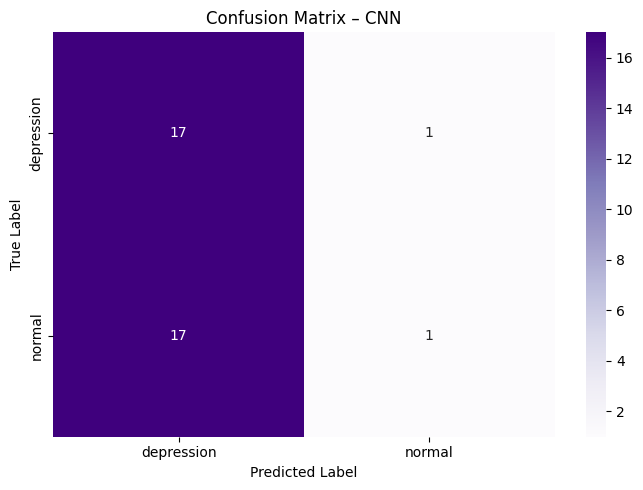

In [22]:
# ── Evaluation ────────────────────────────────────────────────
print("\n" + "=" * 30 + " CNN TEST EVALUATION " + "=" * 30)
y_pred_cnn_prob = best_cnn_model.predict(X_test_cnn).ravel()
y_pred_cnn = (y_pred_cnn_prob >= 0.5).astype(int)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_cnn) * 100:.2f}%")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_cnn, target_names=label_encoder.classes_))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['accuracy'],    label='Train Acc')
axes[0].plot(history.history['val_accuracy'],label='Val Acc')
axes[0].set_title("CNN – Accuracy"); axes[0].legend()
axes[1].plot(history.history['loss'],    label='Train Loss')
axes[1].plot(history.history['val_loss'],label='Val Loss')
axes[1].set_title("CNN – Loss"); axes[1].legend()
plt.tight_layout(); plt.show()

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt="d",
            cmap="Purples", xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – CNN")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

## **TRANSFORMER**

In [23]:
# ══════════════════════════════════════════════════════════════
#  TRANSFORMER  (token-level self-attention on feature patches)
# ══════════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ── Multi-Head Self-Attention block ──────────────────────────
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn  = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_out = self.att(x, x, training=training)
        x = self.norm1(x + self.drop1(attn_out, training=training))
        ffn_out = self.ffn(x)
        return self.norm2(x + self.drop2(ffn_out, training=training))


def build_transformer(input_dim, embed_dim=64, num_heads=4,
                      ff_dim=128, dropout=0.1, learning_rate=0.001):
    """
    Treats each feature as a token of dimension 1, projects to embed_dim,
    applies one Transformer block, then classifies.
    """
    inp = keras.Input(shape=(input_dim,))
    # Project scalar features → embedding vectors  (input_dim, embed_dim)
    x = layers.Reshape((input_dim, 1))(inp)
    x = layers.Dense(embed_dim)(x)                    # (batch, input_dim, embed_dim)

    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [24]:


# ── Hyperparameter grid ───────────────────────────────────────
transformer_param_grid = [
    {'embed_dim': 32,  'num_heads': 2, 'ff_dim': 64,  'dropout': 0.1,  'learning_rate': 0.001},
    {'embed_dim': 64,  'num_heads': 4, 'ff_dim': 128, 'dropout': 0.1,  'learning_rate': 0.001},
    {'embed_dim': 64,  'num_heads': 4, 'ff_dim': 128, 'dropout': 0.2,  'learning_rate': 0.0005},
    {'embed_dim': 128, 'num_heads': 8, 'ff_dim': 256, 'dropout': 0.3,  'learning_rate': 0.0005},
]

best_tr_score  = 0
best_tr_params = None

for params in transformer_param_grid:
    print(f"\n[Transformer] Testing params: {params}")
    fold_scores = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        Xf_tr, Xf_val = X_train[tr_idx], X_train[val_idx]
        yf_tr, yf_val = y_train[tr_idx], y_train[val_idx]

        model = build_transformer(input_dim, **params)
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                           restore_best_weights=True)
        model.fit(Xf_tr, yf_tr,
                  validation_data=(Xf_val, yf_val),
                  epochs=50, batch_size=16,
                  callbacks=[es], verbose=0)

        _, val_acc = model.evaluate(Xf_val, yf_val, verbose=0)
        fold_scores.append(val_acc)
        print(f"   Fold {fold+1}: val_acc = {val_acc:.4f}")

    mean_acc = np.mean(fold_scores)
    print(f"  → Mean CV Accuracy: {mean_acc:.4f}")

    if mean_acc > best_tr_score:
        best_tr_score  = mean_acc
        best_tr_params = params

print(f"\nBest Transformer Params : {best_tr_params}")
print(f"Best CV Accuracy        : {best_tr_score:.4f}")



[Transformer] Testing params: {'embed_dim': 32, 'num_heads': 2, 'ff_dim': 64, 'dropout': 0.1, 'learning_rate': 0.001}
   Fold 1: val_acc = 0.6207
   Fold 2: val_acc = 0.4483
   Fold 3: val_acc = 0.6897
   Fold 4: val_acc = 0.5714
   Fold 5: val_acc = 0.6786
  → Mean CV Accuracy: 0.6017

[Transformer] Testing params: {'embed_dim': 64, 'num_heads': 4, 'ff_dim': 128, 'dropout': 0.1, 'learning_rate': 0.001}
   Fold 1: val_acc = 0.6207
   Fold 2: val_acc = 0.5517
   Fold 3: val_acc = 0.7241
   Fold 4: val_acc = 0.6071
   Fold 5: val_acc = 0.7143
  → Mean CV Accuracy: 0.6436

[Transformer] Testing params: {'embed_dim': 64, 'num_heads': 4, 'ff_dim': 128, 'dropout': 0.2, 'learning_rate': 0.0005}
   Fold 1: val_acc = 0.6207
   Fold 2: val_acc = 0.3793
   Fold 3: val_acc = 0.7586
   Fold 4: val_acc = 0.6071
   Fold 5: val_acc = 0.6786
  → Mean CV Accuracy: 0.6089

[Transformer] Testing params: {'embed_dim': 128, 'num_heads': 8, 'ff_dim': 256, 'dropout': 0.3, 'learning_rate': 0.0005}
   Fold 1: 

In [25]:

# ── Retrain best Transformer on full training set ─────────────
best_tr_model = build_transformer(input_dim, **best_tr_params)
es_final = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                         restore_best_weights=True)
tr_history = best_tr_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, batch_size=16,
    callbacks=[es_final], verbose=1
)


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.5664 - loss: 0.7034 - val_accuracy: 0.5833 - val_loss: 0.7019
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.5315 - loss: 0.6832 - val_accuracy: 0.5833 - val_loss: 0.6799
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.5874 - loss: 0.6679 - val_accuracy: 0.6389 - val_loss: 0.6739
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.5944 - loss: 0.6796 - val_accuracy: 0.5833 - val_loss: 0.6743
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5944 - loss: 0.6694 - val_accuracy: 0.5556 - val_loss: 0.6750
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.6224 - loss: 0.6657 - val_accuracy: 0.5556 - val_loss: 0.6854
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.6014 - loss: 0.6498 - val_accuracy: 0.5833 - val_loss: 0.6778
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.6084 - loss: 0.6581 - val_accuracy: 0.5556 - val_l


============================== TRANSFORMER TEST EVALUATION ==============================


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Test Accuracy: 63.89%

Classification Report:
               precision    recall  f1-score   support

  depression       0.69      0.50      0.58        18
      normal       0.61      0.78      0.68        18

    accuracy                           0.64        36
   macro avg       0.65      0.64      0.63        36
weighted avg       0.65      0.64      0.63        36



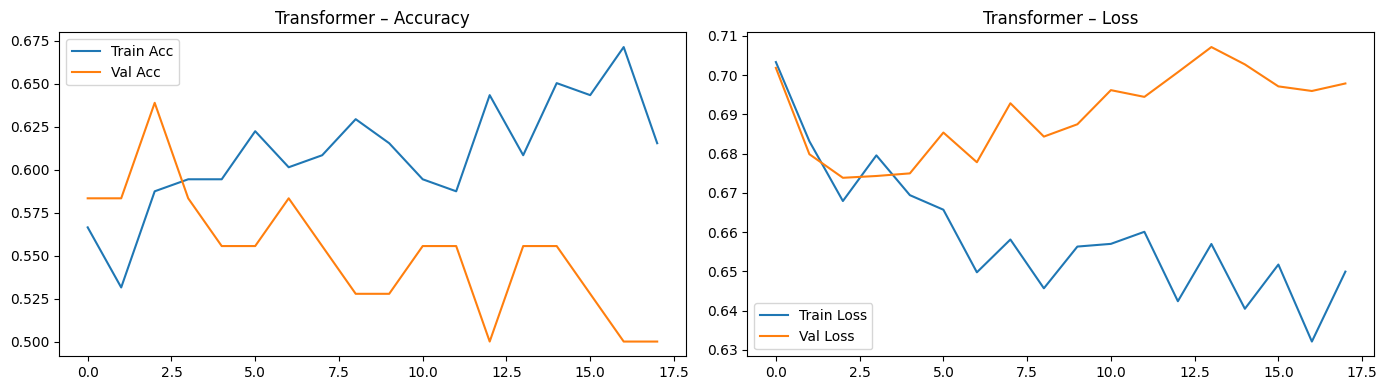

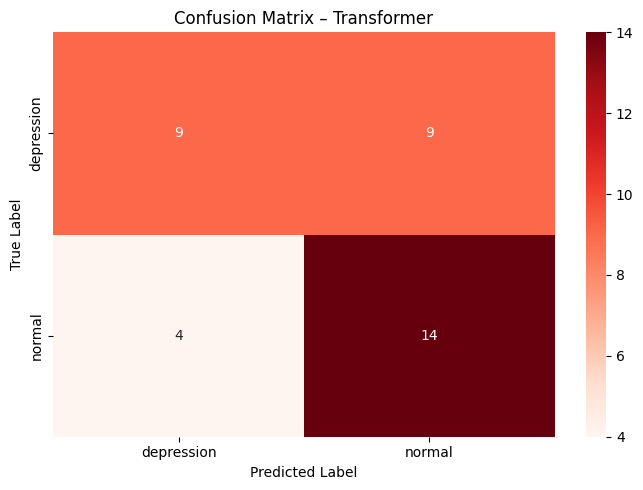

In [26]:

# ── Evaluation ────────────────────────────────────────────────
print("\n" + "=" * 30 + " TRANSFORMER TEST EVALUATION " + "=" * 30)
y_pred_tr_prob = best_tr_model.predict(X_test).ravel()
y_pred_tr = (y_pred_tr_prob >= 0.5).astype(int)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_tr) * 100:.2f}%")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_tr, target_names=label_encoder.classes_))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(tr_history.history['accuracy'],    label='Train Acc')
axes[0].plot(tr_history.history['val_accuracy'],label='Val Acc')
axes[0].set_title("Transformer – Accuracy"); axes[0].legend()
axes[1].plot(tr_history.history['loss'],    label='Train Loss')
axes[1].plot(tr_history.history['val_loss'],label='Val Loss')
axes[1].set_title("Transformer – Loss"); axes[1].legend()
plt.tight_layout(); plt.show()

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_tr), annot=True, fmt="d",
            cmap="Reds", xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – Transformer")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()